# 1. Using Frequentist Regression in Your Own Research

### Import ZTF data

In [1]:
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

# loading lightcurve data
hdul = fits.open('./ztf_3C273_g.fits')
hdul.info()
#header = hdul[0].header
data = Table(hdul[1].data)
df = data.to_pandas()
print('\nExtracted table data:\n', df[:5])
hdul.close()

Filename: ./ztf_3C273_g.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Table         1 BinTableHDU     81   667R x 24C   [1K, 1J, 1D, 1D, 1E, 1E, 1J, 2A, 1D, 1D, 1E, 1E, 1K, 1J, 1B, 1B, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J]   

Extracted table data:
                oid     expid           hjd           mjd        mag    magerr  \
0  473101200004287  45030090  2.458205e+06  58204.300903  13.121748  0.014404   
1  473101200004287  45031700  2.458205e+06  58204.317002  13.115712  0.014409   
2  473101200004287  45630146  2.458211e+06  58210.301470  13.139680  0.014388   
3  473101200004287  45632349  2.458211e+06  58210.323495  13.185056  0.014350   
4  473101200004287  45734530  2.458212e+06  58211.345301  13.133057  0.014394   

   catflags filtercode          ra       dec  ...  ccdid  qid  limitmag  \
0         0         zg  187.277921  2.052420  ...      1    2     20.25   
1         0         zg  187.277911  2.0524

In [2]:
# checking the number of datapoints per colour band/filter (e.g. gri for ztf)
category_counts = df['oid'].value_counts()
category_counts

oid
473101200004287    667
Name: count, dtype: int64

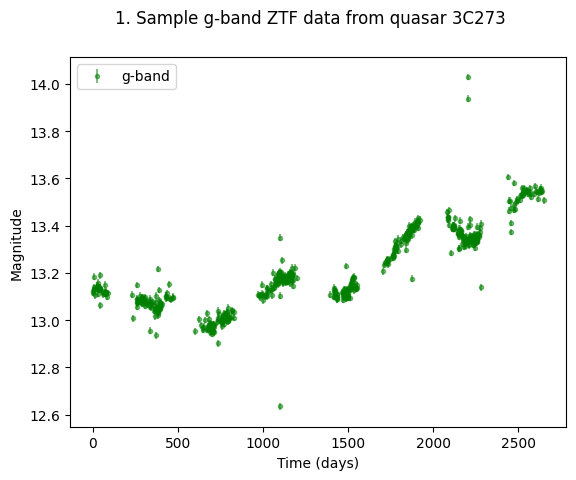

In [3]:
# plotting data +errorbar for chosen filter
ts = df['mjd'].to_numpy()-min(df['mjd'].to_numpy()) # time (in days)
ys = df['mag'].to_numpy() # amplitude (magnitude)
yerrs = df['magerr'].to_numpy() # errorbars


plt.errorbar(ts, ys, yerrs, fmt='.', c='green', alpha=0.5, label='g-band')

plt.suptitle('1. Sample g-band ZTF data from quasar 3C273')
plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

## 1.a. 
To fit the lightcurve of an active galactic nuclei (AGN) we use a damped ramdom wlak (DRW) model.

Our lightcurve data includes time $t$, amplitude $y$, and measurement uncertainty $\sigma$.



### 1.a.i. Our Model
A DRW model is good for modeling AGN lightcurves bc it accounts for the mean-reverting, aperiodic behaviours of AGN. There are also physical interpretations of DRW params (scale, sigma) to AGN properties (black hole mass, luminosity, rest-frame wavelength).

For each data point, our model will fit
$$y_i = \underbrace{\mu(t_i)}_{\text{mean (deterministic) trend}} + \underbrace{X(t_i)}_{\text{DRW (stochastic) process}} + \underbrace{\epsilon_i}_{\text{measurement noise}}$$
where $\mu(t_i)$ is the mean (deterministic) trend (e.g., $ \beta_0 + \beta_1 t_i$), $X(t)$ is DRW stochastic process and $\epsilon_i \sim \mathcal{N}(0, \sigma_i^2)$ is the measurement noise.

- Mean $\mu(t_i)$:

  
  We choose a constant mean $\beta_0$.
  When increasing model complexity in part **1.c.**, we use a polinomial trend mean $ \beta_0 + \beta_1 t_i + +...\beta_k t_i^k$.


- DRW $X(t_i)$ and measurement noise $\epsilon_i$:

  A damped random walk (DRW) is a stochastic process characterised by mean-reverting fluctuations (i.e. the long-term mean is *constant*, not a function of time) and  exponentially correlated fluctuations (i.e. covariance depends on *lag*, not specific time: the relationship between data points decreases exponentially as the time difference between them increases such that short lag points are highly related while large lag points are almost independent).

  The kernel/covariance function $k$, as function of the time difference $\Delta t$ between two measurements, for a DRW is an exponential

  $$k(|\Delta t|)=k_\rm{DRW}(|\Delta t|)=\sigma^2_\rm{DRW}\exp\left({-\left|\frac{\Delta t}{\tau_\rm{DRW}}\right|}\right)=\rm{Cov}_\rm{DRW}(X_i, X_j)$$
    where the two model paramaters are <br>
    - $\tau_\rm{DRW}$: the characteristic (damping/decorrelation) timescale, and <br>
    - $\sigma_\rm{DRW}^2$: the signal variance, or (short-term) variability amplitude.

  Adding measurement uncertainty (white noise) to this stochastic DRW process therefore yeilds a covariance matrix with entries
  $$K_{ij}= \underbrace{k(|t_j-t_i|)}_{\substack{\text{kernel function $k$} \\ \text{at timedelay $|\Delta t_{ij}|=|t_j-t_i|$}}} + \underbrace{\sigma_i^2\delta_{ij}}_{\substack{\text{measurement uncertainty $\sigma_i$} \\  \text{of $i^\text{th}$ observation}}}$$

  where we notice that the measurement error is essentially a diagonal matrix $\text{diag}(\sigma_i^2)$.


### 1.a.ii. Our likelihood

We use a $\chi^2$ likelihood 

Because our data is Gaussian $y\sim\mathcal{N}(\mu, K)$ (both $X(t_i)$ and measurement error $\epsilon_i$ are gaussian processes), the likelihood assumumption of Gaussian errorbars$ f(x) = a \exp(-(x-\mu)^2/2\sigma^2) $ is justified.

So, the probability of the data given the assumed model is that of a [multivariate gaussian](https://en.wikipedia.org/wiki/Multivariate_normal_distribution) model
$$ \begin{aligned}
\mathcal{L} &\propto \prod_i \exp\Big(-\frac{(y_i-m(x_i))^2}{2\sigma_i^2}\Big) \\
&\propto \prod_i\frac{1}{(2\pi)^{N/2} |K|^{1/2}} \exp\Big(-\frac{1}{2} (\mathbf{y}-\boldsymbol{\mu})^T K^{-1} (\mathbf{y}-\boldsymbol{\mu})\Big)
\end{aligned}
$$
such that taking the negative log for numerical stability gives
$$ -\log \mathcal{L} = \sum_i \frac{1}{2} \Big[ (\mathbf{y}-\boldsymbol{\mu})^T K^{-1} (\mathbf{y}-\boldsymbol{\mu}) + \log|K| + N \log(2\pi) \Big] $$


In [4]:
import numpy as np
from numpy.linalg import slogdet, solve

In [5]:
def nll_DRW(params, t, y, sigma):
    """ Calculate negative log likelihood of DRW + constant mean model """
    mu0, log_tau_DRW, log_sigma_DRW = params # unpack params
    
    tau_DRW = np.exp(log_tau_DRW) # DRW timescale
    sigma_DRW = np.exp(log_sigma_DRW) # DRW amplitude
    
    mu = mu0 # constant mean
    r = y - mu # residual/distance
    
    dt = np.abs(t[:, None] - t[None, :]) # time delay matrix 
    K = sigma_DRW**2 * np.exp(-dt / tau_DRW) + np.diag(sigma**2) # cov matrix
    
    sign, logdet = slogdet(K) # log determinant |K|
    quad = r @ solve(K, r) # quad (y-mu)^T K^-1 (y-mu)
    const= len(t) * np.log(2*np.pi) # const N log(2pi)
    
    return 0.5 * (quad + logdet + const)

## 1.b.

We perform our fit using an optimizer in `scipy.optimize`, and plot the results.

In [6]:
from scipy.optimize import minimize

In [7]:
# optimize (MLE using NLL) 

init = [np.mean(ys), np.log(10), np.log(0.1)]

out = minimize(
    nll_DRW,
    init,
    args=(ts, ys, yerrs),
    method="L-BFGS-B"
)

mu_mle, log_tau_mle, log_sigma_mle = out.x
logL = -out.fun

tau_mle = np.exp(log_tau_mle)
sigma_mle = np.exp(log_sigma_mle)

print("MLE estimates:")
print("mu =", mu_mle)
print("tau =", tau_mle)
print("sigma_drw =", sigma_mle)

MLE estimates:
mu = 13.212639808654785
tau = 30.01846574917469
sigma_drw = 0.18401778729312626


I cannot plot the DRW 'fit' directly since it is a stochastic process. To plot it, I would have to generate light curves using the MLE DRW paramaters and plot the probability distibution... like a Gaussian process would.

So, I plotted only the mean function.

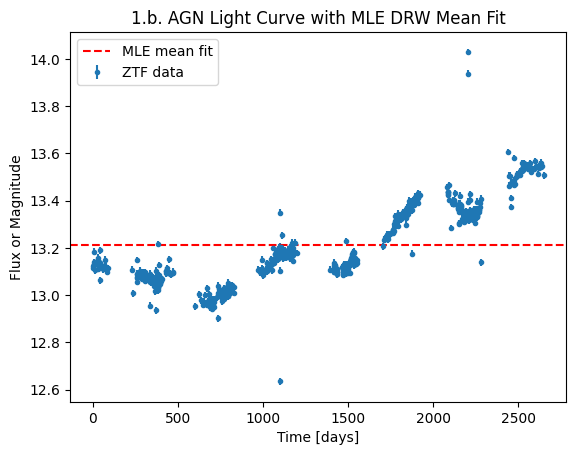

In [8]:
# plot
plt.errorbar(ts, ys, yerr=yerrs, fmt='.', label='ZTF data')
plt.axhline(mu_mle, color='r', linestyle='--', label='MLE mean fit')

plt.xlabel("Time [days]")
plt.ylabel("Flux or Magnitude")
plt.title("1.b. AGN Light Curve with MLE DRW Mean Fit")
plt.legend()
plt.show()

## 1.c.
We perform model selection: we increase the complexity of our model, and identify the correct model to fit the data.

We will be adding paramters to the "mean-fitting" portion of the model. 

**Base model: DRW + offset**
- fits the intrinsic AGN variabitlity (DRW)
- does not assume a trend in mean magnitude (offset $\mu=\text{constant}$)

**Complex model: DRW + polynomial** 
- fits the intrinsic AGN variabitlity (DRW)
- assumes there is a trend in mean magnitude beyond DRW variability (e.g. linear trend $\mu(t)=mt+b$)

We do model selection using the Akaike Information Criterion (AIC) 
$$ AIC = -2\ln[\mathcal{L}_{max}(m)] +2k + \frac{2k(k+1)}{N-k-1}$$
which rewards goodness of fit (with maximum likelihood of model $m$ term) and penalizes model complexity (with number of paramters $k$ and datapoints $N$ terms). 

To further illutrate how increasing model complexity can lead to low bias at the cost of high variance, we show a plot of cross-valodation, where the model is initially trained only half of the data from our ligthcurve (training set) and then validated with the other half of data (validation set).

In [9]:
def nll_DRW_means(params, t, y, sigma):
    """ Calculate negative log likelihood of DRW + some mean model """
    mu, log_tau_DRW, log_sigma_DRW = (None, None, None)
    
    if len(params)==3:
        mu0, log_tau_DRW, log_sigma_DRW = params
        mu = mu0 # constant
        
    elif len(params)==4:
        mu0, m1, log_tau_DRW, log_sigma_DRW = params
        mu = mu0 + m1*t # linear
        
    elif len(params)==5:
        mu0, m1, m2, log_tau_DRW, log_sigma_DRW = params
        mu = mu0 + m1*t + m2*t**2 # quad
        
    elif len(params)==6:
        mu0, m1, m2, m3, log_tau_DRW, log_sigma_DRW = params
        mu = mu0 + m1*t + m2*t**2 + m3*t**3 # cubic
    
    tau_DRW = np.exp(log_tau_DRW) # DRW timescale
    sigma_DRW = np.exp(log_sigma_DRW) # DRW amplitude
    
    r = y - mu # residual/distance
    
    dt = np.abs(t[:, None] - t[None, :]) # time delay matrix 
    K = sigma_DRW**2 * np.exp(-dt / tau_DRW) + np.diag(sigma**2) # cov matrix
    
    sign, logdet = slogdet(K) # log determinant |K|
    quad = r @ solve(K, r) # quad (y-mu)^T K^-1 (y-mu)
    const= len(t) * np.log(2*np.pi) # const N log(2pi)
    
    return 0.5 * (quad + logdet + const)

In [10]:
def AIC(logL, k, N):
    return  -2*logL + 2*k + (2*k*(k+1))/(N-k-1)

In [11]:
# I want to try cross-validation
# 20/80 training/validation split
split = int(0.2 * len(ts))

ts_val, ts_train = ts[:split], ts[split:]
ys_val, ys_train = ys[:split], ys[split:]
yerrs_val, yerrs_train = yerrs[:split], yerrs[split:]

In [12]:
# model comparison plot

ks = [3,4,5,6] # nbr of params/model
N = len(ts)
k_params = []
k_logL_train = []
k_logL_val = []
k_aic = []

for k in ks:
    # inital guess
    init_mean = np.zeros(k-2)
    init_mean[0] = np.median(ys)
    init = [*init_mean, np.log(10), np.log(0.1)]

    # optimize (MLE)
    out = minimize(nll_DRW_means, init, args=(ts_train, ys_train, yerrs_train), method="L-BFGS-B")
    params = out.x
    logL = -out.fun # training
    logL_val = -nll_DRW_means(params, ts_val, ys_val, yerrs_val) # validatiom

    # model comparison
    aic = AIC(logL, k, N)

    # save 
    k_params.append(params)
    k_logL_train.append(logL)
    k_logL_val.append(logL_val)
    k_aic.append(aic)

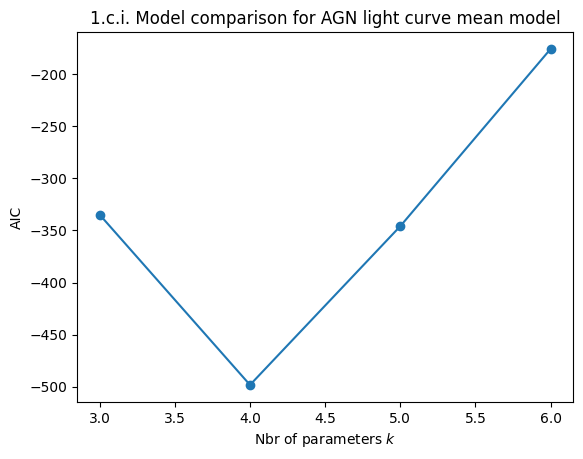

In [13]:
plt.plot(figsize=(10,5))
plt.title('1.c.i. Model comparison for AGN light curve mean model')
plt.plot(ks, k_aic, 'o-')
plt.xlabel(r'Nbr of parameters $k$')
plt.ylabel('AIC')
plt.show()

From this plot it seems that the AIC of the linear model is best fit (lowest AIC), but doing cross-validation we can look at bias-variance tradeoff.

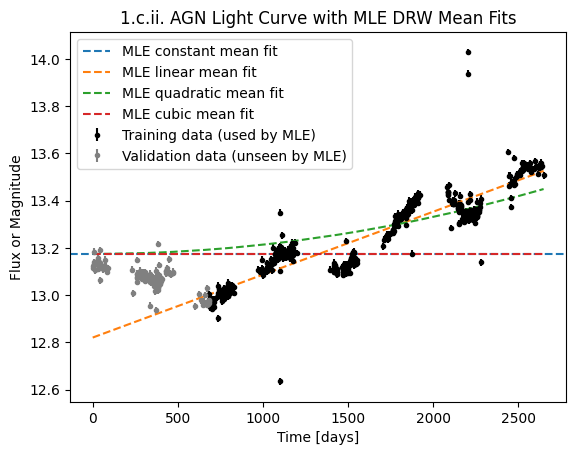

In [14]:
# plot
plt.errorbar(ts_train, ys_train, yerr=yerrs_train, c='k', fmt='.', label='Training data (used by MLE)')
plt.errorbar(ts_val, ys_val, yerr=yerrs_val, c='grey', fmt='.', label='Validation data (unseen by MLE)')

plt.axhline(k_params[0][0], linestyle='--', c='C0', label='MLE constant mean fit')
plt.plot(ts, k_params[1][0]+ts*(k_params[1][1]), linestyle='--', c='C1', label='MLE linear mean fit')
plt.plot(ts, k_params[2][0]+ts*(k_params[2][1])+ts**2*(k_params[2][2]), linestyle='--', c='C2', label='MLE quadratic mean fit')
plt.plot(ts, k_params[3][0]+ts*(k_params[3][1])+ts**2*(k_params[3][2])+ts**3*(k_params[3][3]), linestyle='--', c='C3', label='MLE cubic mean fit')

plt.xlabel("Time [days]")
plt.ylabel("Flux or Magnitude")
plt.title("1.c.ii. AGN Light Curve with MLE DRW Mean Fits")
plt.legend()
plt.show()

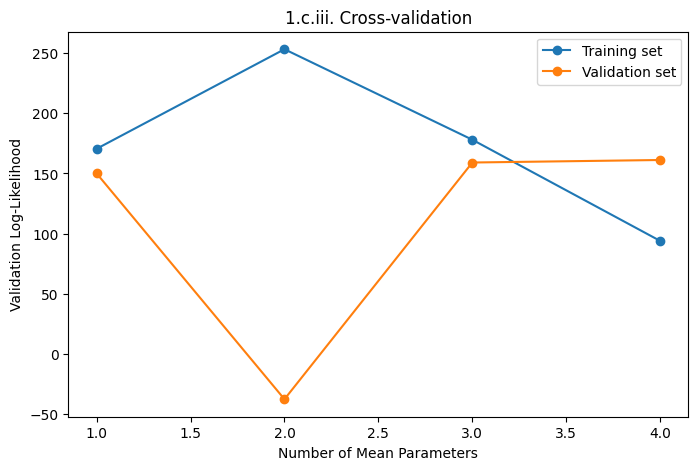

In [15]:
mean_params = [k-2 for k in ks]

plt.figure(figsize=(8,5))
plt.plot(mean_params, k_logL_train, 'o-', label='Training set')
plt.plot(mean_params, k_logL_val, 'o-', label='Validation set')
plt.xlabel("Number of Mean Parameters")
plt.ylabel("Validation Log-Likelihood")
plt.title("1.c.iii. Cross-validation")
plt.legend()
plt.show()

From the cross validation, the best fit (lowest AIC) from figure 1.c.i. (i.e. the linear, 2 param mean model) does not predict the validation data well. From plot 1.c.ii. and 1.c.iii. we see from cross-validation that the simplest model (i.e. the constant, 1 param mean model) has the best balance of bias and variance. 

Note: Since we did a really rough split of the data (a chronological split), I would have to try this again with more data to trust it...